
=== Replicon Ranking ===
                  rep  n_partners  mean_cointegration  median_cointegration  \
212  rep_cluster_2120           1                 1.0                   1.0   
160  rep_cluster_1751           1                 1.0                   1.0   
236  rep_cluster_2283           3                 1.0                   1.0   
282   rep_cluster_398           1                 1.0                   1.0   
55   rep_cluster_1057           1                 1.0                   1.0   
..                ...         ...                 ...                   ...   
370   rep_cluster_800           5                 0.0                   0.0   
3          Col(KPHS6)           1                 0.0                   0.0   
2           Col(IRGK)           5                 0.0                   0.0   
390   rep_cluster_991           5                 0.0                   0.0   
1         Col(IMGS31)           2                 0.0                   0.0   

     sd_cointegration    

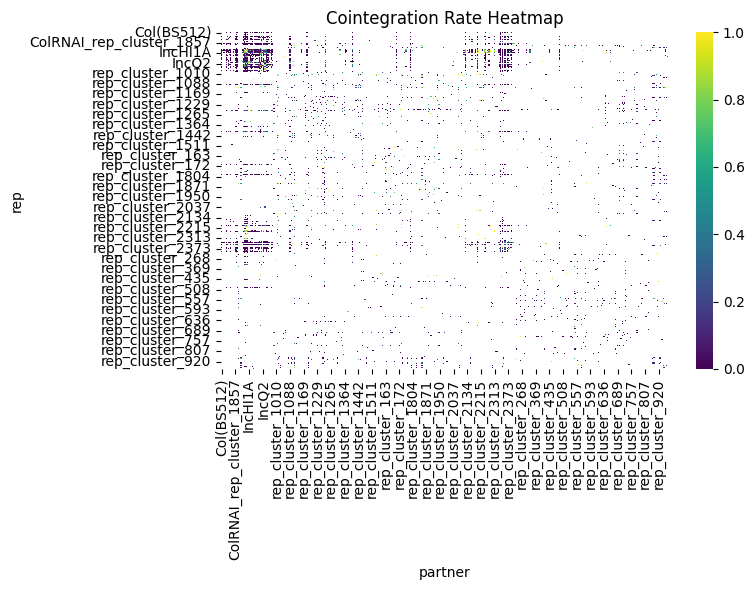

In [1]:
# ============================================================
# ANALYSIS: Replicon-level cointegration tendency
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("replicon_cointegration_conditional.csv", sep=",")

# ------------------------------------------------------------
# 2. MAKE SYMMETRIC (undirected network)
# ------------------------------------------------------------

df_rev = df.copy()
df_rev = df_rev.rename(columns={"repA": "repB", "repB": "repA"})

df_long = pd.concat([df[["repA","repB","cointegration_rate"]],
                     df_rev[["repA","repB","cointegration_rate"]]],
                     ignore_index=True)

df_long.columns = ["rep", "partner", "cointegration_rate"]

# ------------------------------------------------------------
# 3. REPLICÓN-LEVEL METRICS
# ------------------------------------------------------------

rep_stats = (
    df_long
    .groupby("rep")
    .agg(
        n_partners = ("partner", "nunique"),
        mean_cointegration = ("cointegration_rate", "mean"),
        median_cointegration = ("cointegration_rate", "median"),
        sd_cointegration = ("cointegration_rate", "std")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4. GLOBAL Z-SCORE
# ------------------------------------------------------------

global_mean = df_long["cointegration_rate"].mean()
global_sd = df_long["cointegration_rate"].std()

rep_stats["z_mean"] = (
    (rep_stats["mean_cointegration"] - global_mean) / global_sd
)

# ------------------------------------------------------------
# 5. CLASSIFICATION
# ------------------------------------------------------------

def classify(z):
    if z > 1.5:
        return "STRONG_PROMISCUOUS"
    elif z < -1.5:
        return "STRONG_REPELENT"
    else:
        return "NEUTRAL"

rep_stats["behavior"] = rep_stats["z_mean"].apply(classify)

# ------------------------------------------------------------
# 6. SORT RANKING
# ------------------------------------------------------------

rep_stats = rep_stats.sort_values("mean_cointegration", ascending=False)

print("\n=== Replicon Ranking ===")
print(rep_stats)

# ------------------------------------------------------------
# 7. HEATMAP (matrix form)
# ------------------------------------------------------------

matrix = df_long.pivot(index="rep", columns="partner", values="cointegration_rate")

plt.figure(figsize=(8,6))
sns.heatmap(matrix, cmap="viridis", vmin=0, vmax=1)
plt.title("Cointegration Rate Heatmap")
plt.tight_layout()
plt.show()

Replicons kept (>= 3 partners): 262


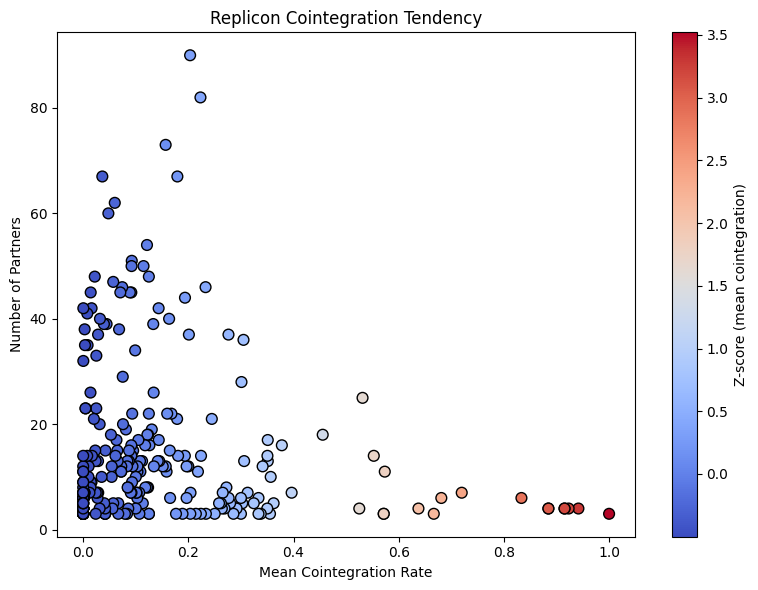

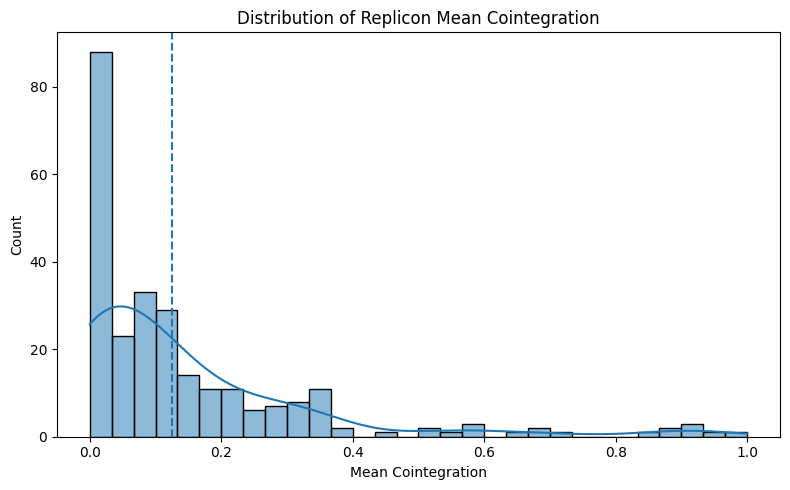

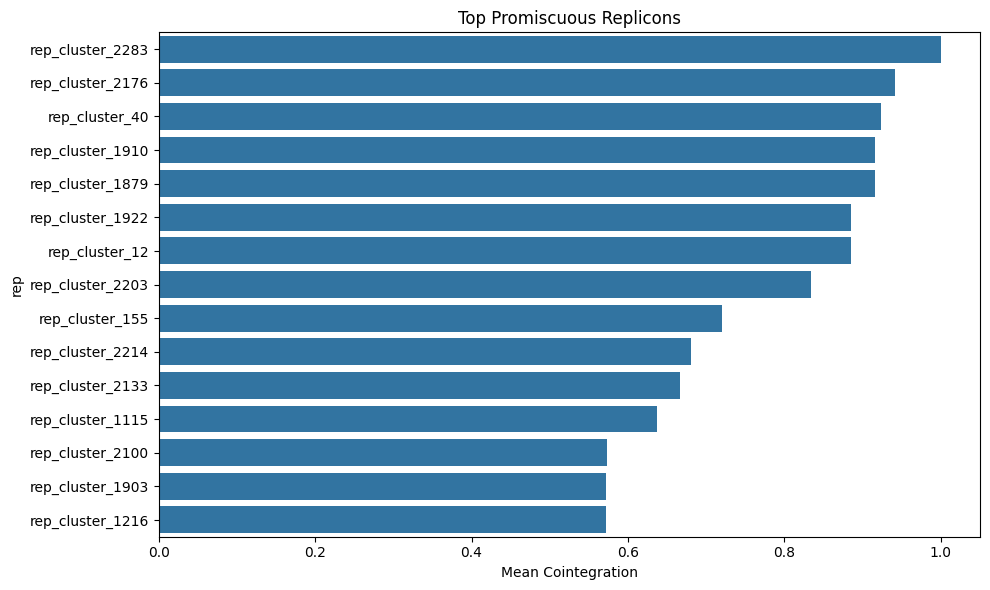

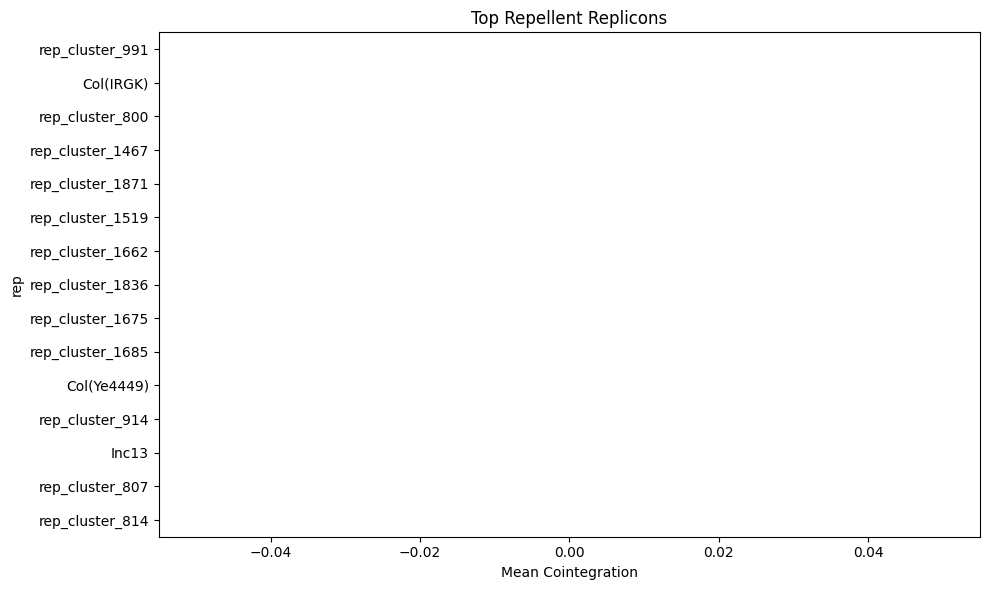

In [4]:
# ============================================================
# BETTER VISUALIZATION OF REPLICÓN BEHAVIOR
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# 1. FILTER: require enough partners
# ------------------------------------------------------------

MIN_PARTNERS = 3
rep_filt = rep_stats[rep_stats["n_partners"] >= MIN_PARTNERS].copy()

print(f"Replicons kept (>= {MIN_PARTNERS} partners): {len(rep_filt)}")

# ------------------------------------------------------------
# 2. VOLCANO-LIKE PLOT
# x = mean cointegration
# y = number of partners
# color = z-score
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    rep_filt["mean_cointegration"],
    rep_filt["n_partners"],
    c=rep_filt["z_mean"],
    cmap="coolwarm",
    s=60,
    edgecolor="black"
)

plt.colorbar(scatter, label="Z-score (mean cointegration)")
plt.xlabel("Mean Cointegration Rate")
plt.ylabel("Number of Partners")
plt.title("Replicon Cointegration Tendency")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. DISTRIBUTION OF MEAN COINTEGRATION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(rep_filt["mean_cointegration"], bins=30, kde=True)

plt.axvline(global_mean, linestyle="--")
plt.title("Distribution of Replicon Mean Cointegration")
plt.xlabel("Mean Cointegration")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. TOP / BOTTOM REPLICONS (BARPLOT)
# ------------------------------------------------------------

TOP_N = 15

top = rep_filt.sort_values("mean_cointegration", ascending=False).head(TOP_N)
bottom = rep_filt.sort_values("mean_cointegration", ascending=True).head(TOP_N)

plt.figure(figsize=(10,6))
sns.barplot(
    x="mean_cointegration",
    y="rep",
    data=top,
)
plt.title("Top Promiscuous Replicons")
plt.xlabel("Mean Cointegration")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
sns.barplot(
    x="mean_cointegration",
    y="rep",
    data=bottom,
)
plt.title("Top Repellent Replicons")
plt.xlabel("Mean Cointegration")
plt.tight_layout()
plt.show()